In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/belovedorange/research-methodology-project/node_22_wind_actual.csv
/kaggle/input/datasets/belovedorange/research-methodology-project/node_33_PV_actual.csv
/kaggle/input/datasets/belovedorange/research-methodology-project/node_25_wind_actual.csv
/kaggle/input/datasets/belovedorange/research-methodology-project/node_18_PV_actual.csv


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Load wind datasets
w22 = pd.read_csv("/kaggle/input/datasets/belovedorange/research-methodology-project/node_22_wind_actual.csv")
w25 = pd.read_csv("/kaggle/input/datasets/belovedorange/research-methodology-project/node_25_wind_actual.csv")

print("W22 Shape:", w22.shape)
print("W25 Shape:", w25.shape)

W22 Shape: (35040, 501)
W25 Shape: (35040, 501)


In [3]:
# Remove timestamp column
w22_num = w22.drop(columns=["timestamp"])
w25_num = w25.drop(columns=["timestamp"])

# Convert to numeric
w22_num = w22_num.apply(pd.to_numeric, errors='coerce')
w25_num = w25_num.apply(pd.to_numeric, errors='coerce')

# Flatten data
w22_vals = w22_num.values.flatten()
w25_vals = w25_num.values.flatten()

# Remove NaN values
w22_vals = w22_vals[~np.isnan(w22_vals)]
w25_vals = w25_vals[~np.isnan(w25_vals)]

print("Samples W22:", len(w22_vals))
print("Samples W25:", len(w25_vals))

Samples W22: 17520000
Samples W25: 17520000


In [4]:
print("Mean W22:", np.mean(w22_vals))
print("Mean W25:", np.mean(w25_vals))

print("Variance W22:", np.var(w22_vals))
print("Variance W25:", np.var(w25_vals))

Mean W22: 0.03989180100735024
Mean W25: 0.029811072602305904
Variance W22: 0.0018246041299101114
Variance W25: 0.0009578945746891724


In [5]:
t_stat, p_val_t = stats.ttest_ind(w22_vals, w25_vals)

print("T-statistic:", t_stat)
print("P-value:", p_val_t)

T-statistic: 799.9106283274278
P-value: 0.0


In [6]:
var22 = np.var(w22_vals)
var25 = np.var(w25_vals)

F = var22 / var25

df1 = len(w22_vals) - 1
df2 = len(w25_vals) - 1

p_val_f = 2 * min(stats.f.cdf(F, df1, df2), 1 - stats.f.cdf(F, df1, df2))

print("F-statistic:", F)
print("P-value:", p_val_f)

F-statistic: 1.9048068316935378
P-value: 2.220446049250313e-16


In [7]:
alpha = 0.05

print("\n===== FINAL CONCLUSION =====")

# T-test
if p_val_t < alpha:
    print("Reject H0 → Means are different")
else:
    print("Accept H0 → Means are same")

# F-test
if p_val_f < alpha:
    print("Reject H0 → Variability is different")
else:
    print("Accept H0 → Variability is same")


===== FINAL CONCLUSION =====
Reject H0 → Means are different
Reject H0 → Variability is different


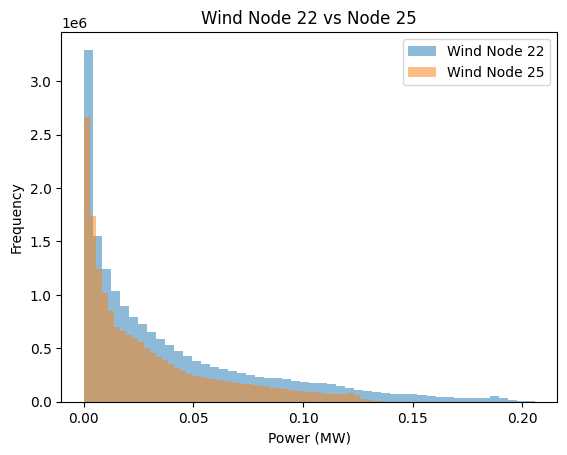

In [8]:
plt.figure()
plt.hist(w22_vals, bins=50, alpha=0.5, label="Wind Node 22")
plt.hist(w25_vals, bins=50, alpha=0.5, label="Wind Node 25")

plt.legend()
plt.title("Wind Node 22 vs Node 25")
plt.xlabel("Power (MW)")
plt.ylabel("Frequency")

plt.show()